In [1]:
#Importing Libraries
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error,mean_absolute_error

In [2]:
#Importing Dataset
df = pd.read_csv("Salary Data.csv")

In [3]:
df

,Education Level,Job Title,Years of Experience,Salary
0,Bachelor's,Software Engineer,5.0,90000.0
1,Master's,Data Analyst,3.0,65000.0
2,PhD,Senior Manager,15.0,150000.0
3,Bachelor's,Sales Associate,7.0,60000.0
4,Master's,Director,20.0,200000.0
...,...,...,...,...
370,Bachelor's,Senior Marketing Analyst,8.0,85000.0
371,Master's,Director of Operations,19.0,170000.0
372,Bachelor's,Junior Project Manager,2.0,40000.0
373,Bachelor's,Senior Operations Coordinator,7.0,90000.0


In [4]:
df.head()

,Education Level,Job Title,Years of Experience,Salary
0,Bachelor's,Software Engineer,5.0,90000.0
1,Master's,Data Analyst,3.0,65000.0
2,PhD,Senior Manager,15.0,150000.0
3,Bachelor's,Sales Associate,7.0,60000.0
4,Master's,Director,20.0,200000.0


In [5]:
df.tail()

,Education Level,Job Title,Years of Experience,Salary
370,Bachelor's,Senior Marketing Analyst,8.0,85000.0
371,Master's,Director of Operations,19.0,170000.0
372,Bachelor's,Junior Project Manager,2.0,40000.0
373,Bachelor's,Senior Operations Coordinator,7.0,90000.0
374,PhD,Senior Business Analyst,15.0,150000.0


In [6]:
df.columns

Index(['Education Level', 'Job Title', 'Years of Experience', 'Salary'], dtype='object')

In [7]:
df.describe()

,Years of Experience,Salary
count,373.000000,373.000000
mean,10.030831,100577.345845
std,6.557007,48240.013482
min,0.000000,350.000000
25%,4.000000,55000.000000
50%,9.000000,95000.000000
75%,15.000000,140000.000000
max,25.000000,250000.000000


In [8]:
df.shape

(375, 4)

In [9]:
#Getting the infromation present in the data set
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 375 entries, 0 to 374
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Education Level      373 non-null    object 
 1   Job Title            373 non-null    object 
 2   Years of Experience  373 non-null    float64
 3   Salary               373 non-null    float64
dtypes: float64(2), object(2)
memory usage: 11.8+ KB


In [10]:
df.dtypes

Education Level         object
Job Title               object
Years of Experience    float64
Salary                 float64
dtype: object

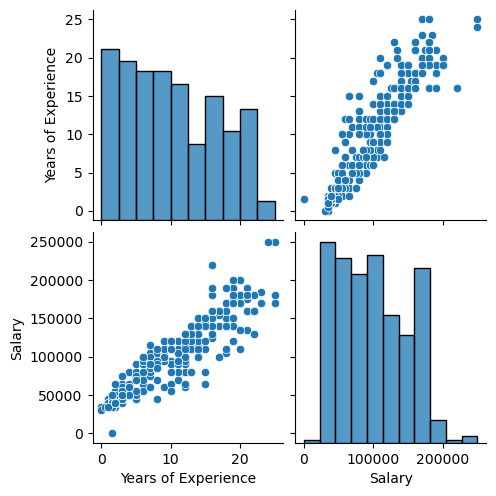

In [11]:
sns.pairplot(df)

In [13]:
df.isnull().sum()

Education Level        2
Job Title              2
Years of Experience    2
Salary                 2
dtype: int64

In [14]:
df.dropna(inplace=True)

In [23]:
df.duplicated().sum()

61

In [24]:
df = df.drop_duplicates()


In [25]:
df = df.apply(lambda x: x.str.strip() if x.dtype == "object" else x)


In [26]:
df.duplicated().sum()

0

In [30]:
df.head()

,Education Level,Job Title,Years of Experience,Salary
0,Bachelor's,Software Engineer,5.0,90000.0
1,Master's,Data Analyst,3.0,65000.0
2,PhD,Senior Manager,15.0,150000.0
3,Bachelor's,Sales Associate,7.0,60000.0
4,Master's,Director,20.0,200000.0


In [31]:
df.shape

(312, 4)

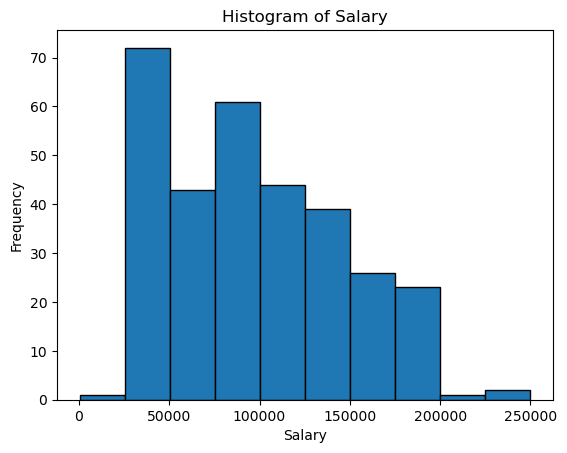

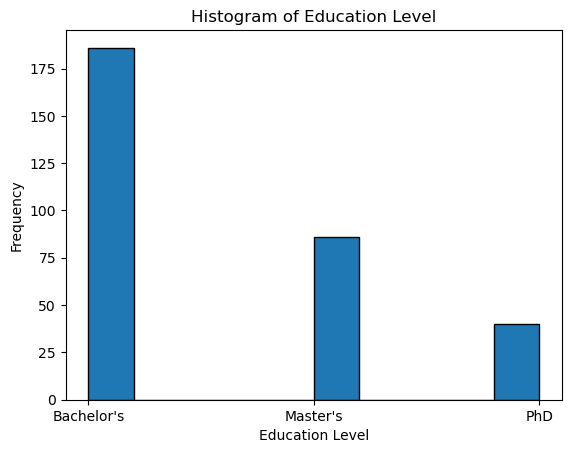

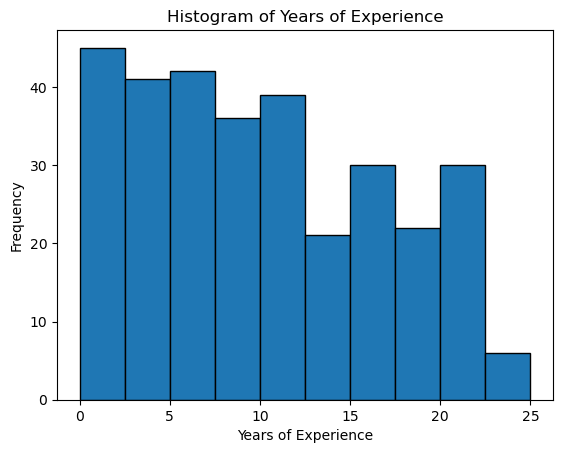

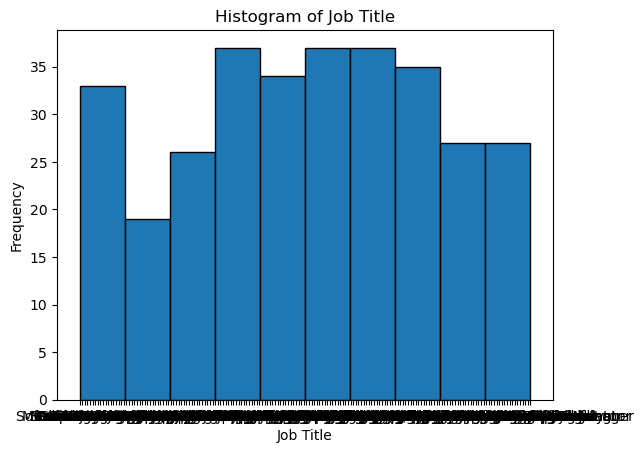

In [35]:
import matplotlib.pyplot as plt

# Plotting histograms for continuous features
continuous_features = ['Salary', 'Education Level', 'Years of Experience', 'Job Title']

for feature in continuous_features:
    plt.hist(df[feature], bins=10, edgecolor='black')
    plt.title(f'Histogram of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')
    plt.show()


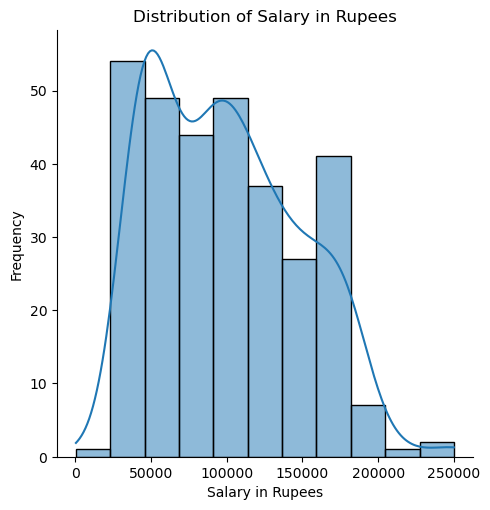

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plot distribution of 'Salary in Rupees'
sns.displot(df['Salary'], kde=True)
plt.title('Distribution of Salary in Rupees')
plt.xlabel('Salary in Rupees')
plt.ylabel('Frequency')
plt.show()


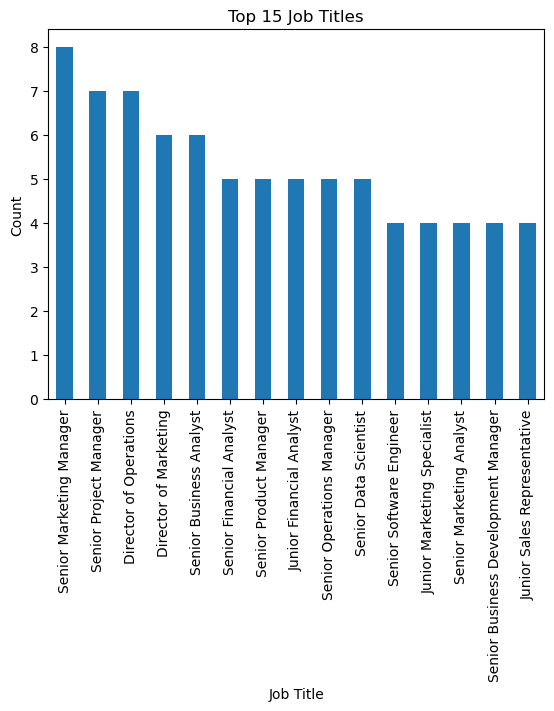

In [45]:
# Getting the top 15 job titles
top_15_jobs = df['Job Title'].value_counts().head(15)

# Plot a bar plot
top_15_jobs.plot(kind='bar')
plt.title('Top 15 Job Titles')
plt.xlabel('Job Title')
plt.ylabel('Count')
plt.show()

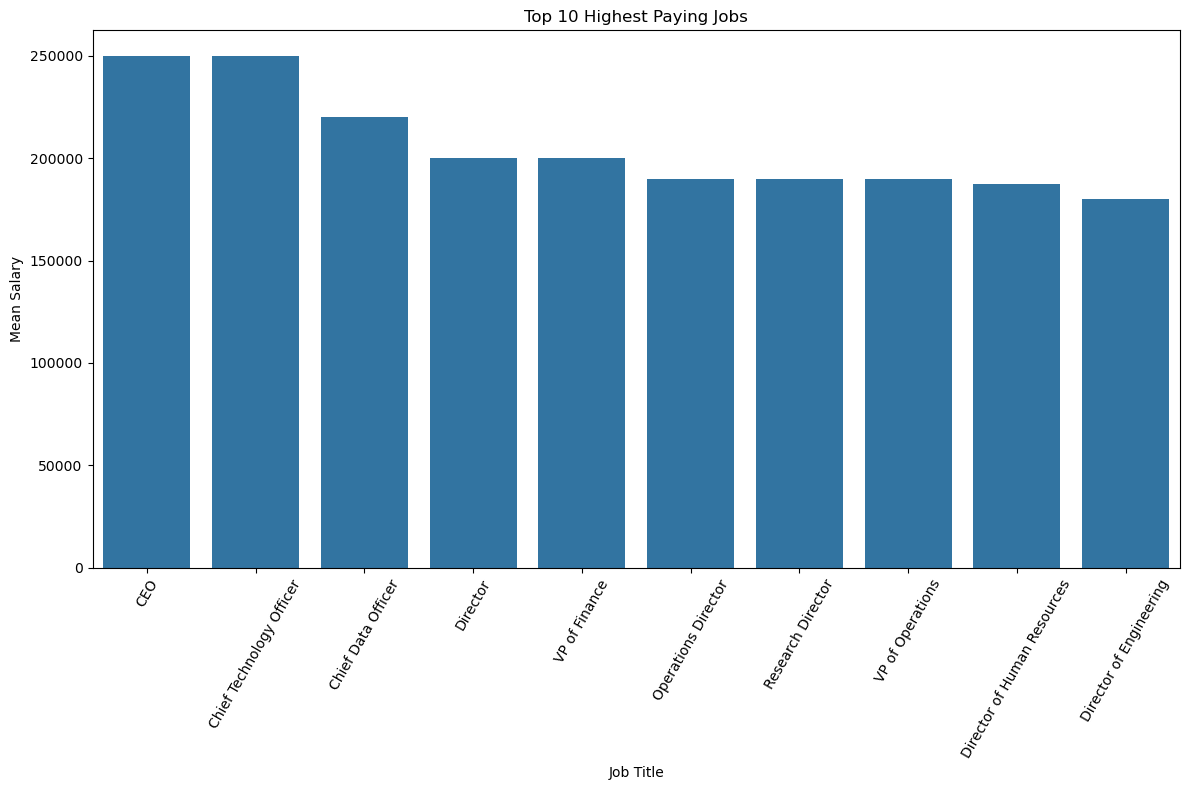

In [46]:
# Get the top 10 job titles with the highest mean salary
top_10_highest_paying_jobs = df.groupby('Job Title')['Salary'].mean().nlargest(10)

# Create a single bar plot for the top 10 highest paying job titles and their mean salaries
plt.figure(figsize=(12, 8))
sns.barplot(x=top_10_highest_paying_jobs.index, y=top_10_highest_paying_jobs.values)

# Customize the plot
plt.xlabel('Job Title')
plt.ylabel('Mean Salary')
plt.title('Top 10 Highest Paying Jobs')
plt.xticks(rotation=60)  # Rotate x-axis labels if needed

# Show the plot
plt.tight_layout()
plt.show()

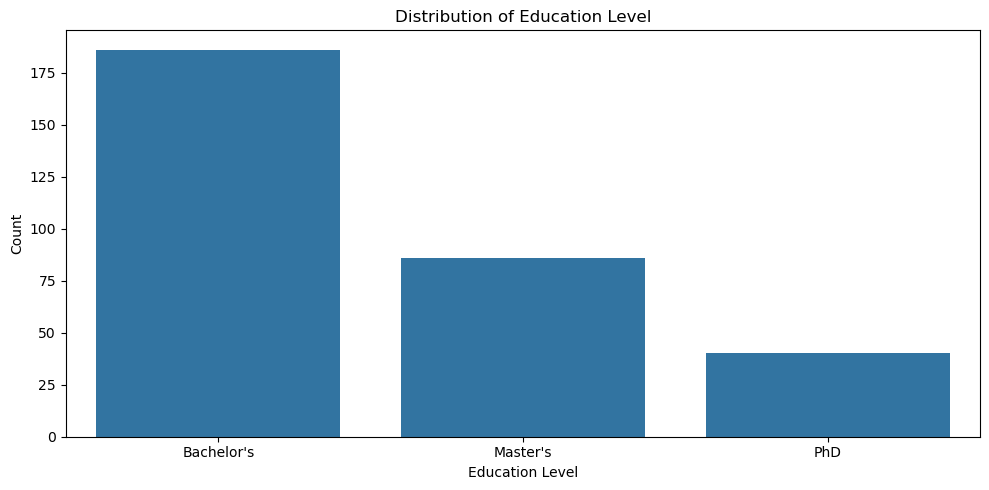

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a figure with one subplot (just for the Education Level plot)
fig, ax = plt.subplots(figsize=(10, 5))

# Plot the count of data points for each education level category
sns.countplot(x='Education Level', data=df, ax=ax)

# Add labels and title
ax.set_xlabel('Education Level')
ax.set_ylabel('Count')
ax.set_title('Distribution of Education Level')

# Show the plot
plt.tight_layout()
plt.show()


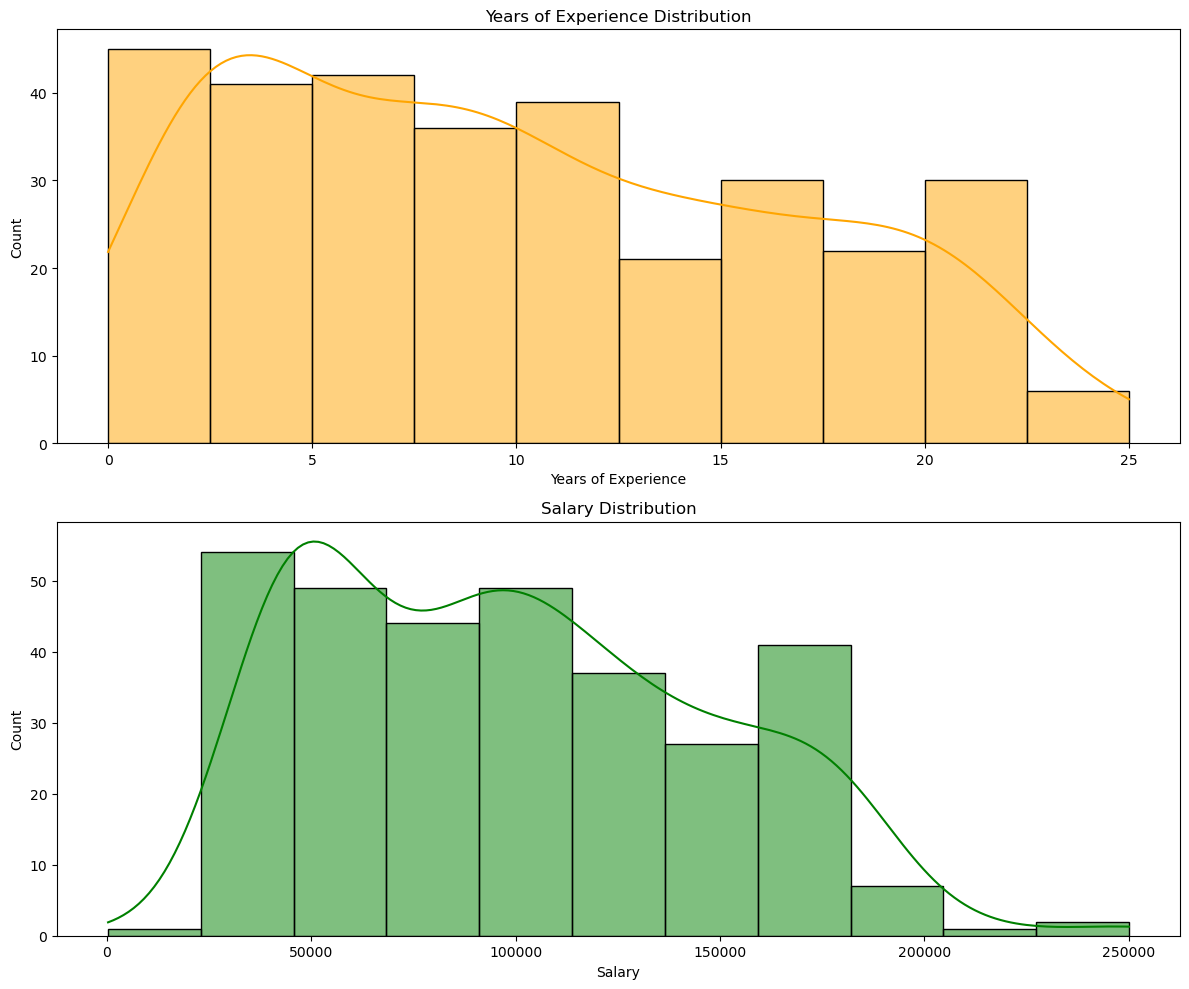

In [61]:
# Create a figure with two subplots (second and third only)
fig, ax = plt.subplots(2, 1, figsize=(12, 10))

# Create a histogram of Years of Experience in the first subplot
sns.histplot(df['Years of Experience'], ax=ax[0], color='orange', kde=True)
ax[0].set_title('Years of Experience Distribution')
ax[0].set_xlabel('Years of Experience')

# Create a histogram of Salary in the second subplot
sns.histplot(df['Salary'], ax=ax[1], color='green', kde=True)
ax[1].set_title('Salary Distribution')
ax[1].set_xlabel('Salary')

plt.tight_layout()
plt.show()


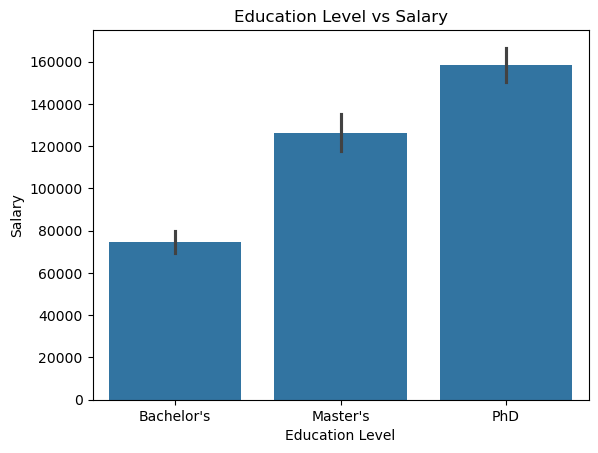

In [63]:
sns.barplot(x='Education Level', y='Salary', data=df).set(title='Education Level vs Salary')
plt.show()

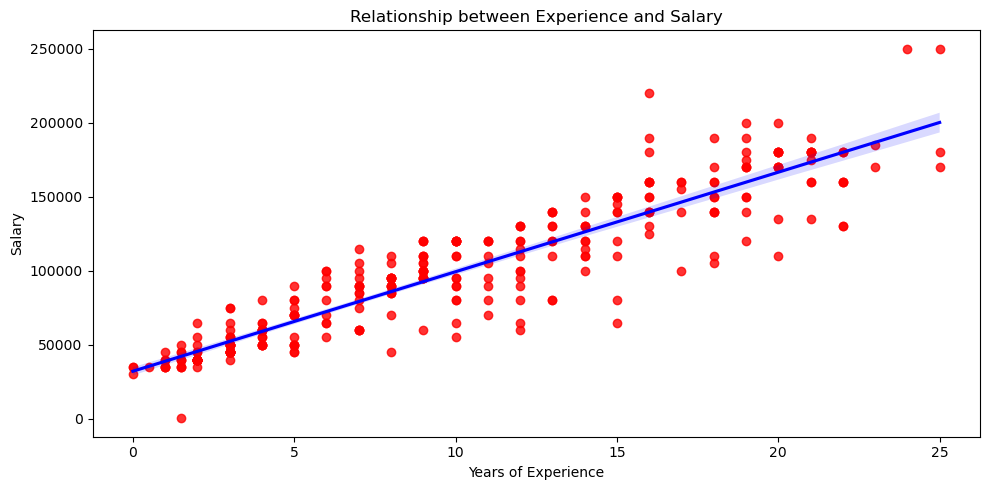

In [65]:
# Create a figure with one subplot for the relationship between experience and salary
fig, ax = plt.subplots(1, 1, figsize=(10, 5))

# Scatter plot for relationship between experience and salary
sns.regplot(x='Years of Experience', y='Salary', data=df, scatter_kws={'color':'red'}, line_kws={'color':'blue'}, ax=ax)
ax.set(title='Relationship between Experience and Salary')

plt.tight_layout()
plt.show()


In [67]:
df['Job Title'].unique()

array(['Software Engineer', 'Data Analyst', 'Senior Manager',
       'Sales Associate', 'Director', 'Marketing Analyst',
       'Product Manager', 'Sales Manager', 'Marketing Coordinator',
       'Senior Scientist', 'Software Developer', 'HR Manager',
       'Financial Analyst', 'Project Manager', 'Customer Service Rep',
       'Operations Manager', 'Marketing Manager', 'Senior Engineer',
       'Data Entry Clerk', 'Sales Director', 'Business Analyst',
       'VP of Operations', 'IT Support', 'Recruiter', 'Financial Manager',
       'Social Media Specialist', 'Software Manager', 'Junior Developer',
       'Senior Consultant', 'Product Designer', 'CEO', 'Accountant',
       'Data Scientist', 'Marketing Specialist', 'Technical Writer',
       'HR Generalist', 'Project Engineer', 'Customer Success Rep',
       'Sales Executive', 'UX Designer', 'Operations Director',
       'Network Engineer', 'Administrative Assistant',
       'Strategy Consultant', 'Copywriter', 'Account Manager',
      

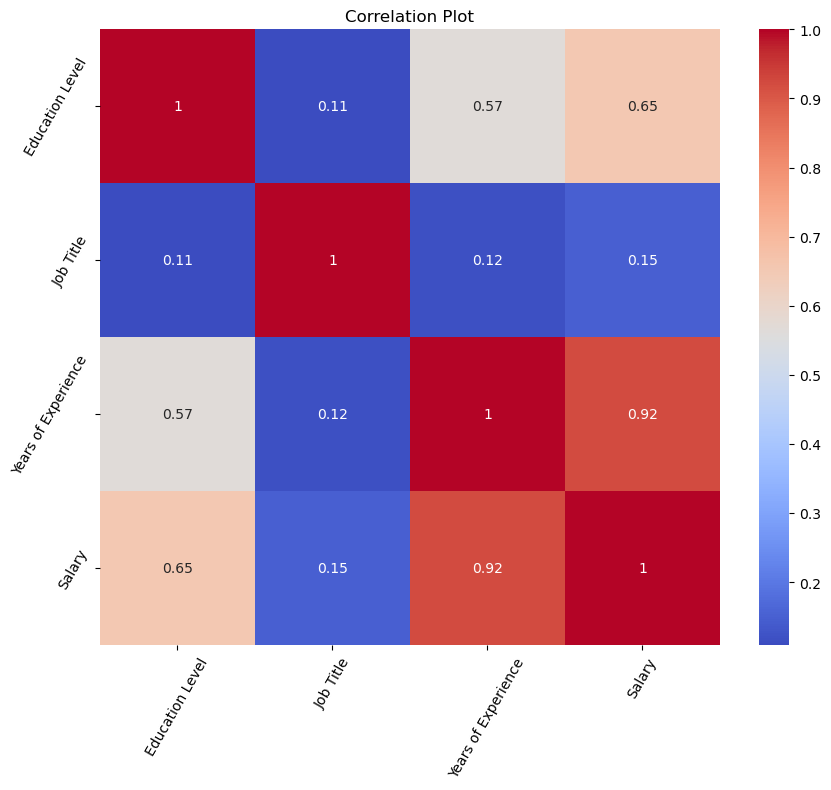

In [69]:
# Identify non-numeric columns and apply Label Encoding
categorical_columns = df.select_dtypes(include=['object']).columns

# Apply LabelEncoder to each categorical column
for col in categorical_columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

# Correlation plot after converting all non-numeric columns
plt.figure(figsize=(10, 8))  # Set the figure size
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')  # Use cmap for color map
plt.title('Correlation Plot')
plt.xticks(rotation=60)  # Rotate x-axis labels for better visibility
plt.yticks(rotation=60)  # Rotate y-axis labels for better visibility
plt.show()


In [73]:
# Splitting the data into x and y for training and testing purpose
x = df[['Education Level', 'Job Title', 'Years of Experience']]

# Check the shape of x
print(x.shape)


(312, 3)


In [74]:
x.head(5)

,Education Level,Job Title,Years of Experience
0,0,159,5.0
1,1,17,3.0
2,2,130,15.0
3,0,101,7.0
4,1,22,20.0


In [75]:
y=df[['Salary']]
y.head(5)

,Salary
0,90000.0
1,65000.0
2,150000.0
3,60000.0
4,200000.0


In [76]:
# Splitting the above data into training and testing data
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size= 0.2,random_state = 9598)

In [77]:
# to know about the shape of traing and testing data

print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(249, 3)
(63, 3)
(249, 1)
(63, 1)


In [78]:
# Linear Regression
from sklearn.linear_model import LinearRegression
model = LinearRegression()

In [79]:
# To train and fit the model
model.fit(x_train,y_train)

LinearRegression()

In [80]:
# to predict the data
y_pred = model.predict(x_test)
y_pred

array([[153839.2489935 ],
       [ 56634.62508309],
       [ 49730.8299492 ],
       [ 84261.65190487],
       [ 60614.43738821],
       [103192.21471409],
       [176619.78375121],
       [168453.90280028],
       [ 52612.85152261],
       [ 87802.85852706],
       [ 55585.61210523],
       [102064.61587241],
       [154658.08250889],
       [ 44605.38066881],
       [153480.46754387],
       [ 40937.74193923],
       [ 72723.5060358 ],
       [ 81031.38048875],
       [ 94473.06594924],
       [ 61588.27275149],
       [ 87751.60403425],
       [ 40886.48744643],
       [171072.528552  ],
       [ 43426.52733432],
       [ 82056.47034483],
       [ 45117.92559685],
       [142084.31517682],
       [ 99295.63489152],
       [ 55534.35761243],
       [125460.20454377],
       [191183.18306519],
       [117354.87132308],
       [161066.13247885],
       [116739.81740943],
       [ 89289.23881837],
       [ 35806.40767065],
       [173539.86756426],
       [124389.74518308],
       [ 681

In [81]:
# to know what the orignal prediction was for the testing data
y_test

,Salary
335,170000.0
203,45000.0
35,45000.0
215,100000.0
198,55000.0
...,...
46,75000.0
276,160000.0
189,35000.0
75,95000.0


In [82]:
# to Calculate the Accuracy of the Model
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error,mean_squared_error

In [83]:
# to print the mean absolute error
mean_absolute_error(y_test,y_pred)

12855.881707651117

In [84]:
# to print the mean absolute percentage
per_e = mean_absolute_percentage_error(y_test,y_pred)
per_e

0.1332855547986879

In [85]:
# to print the accuracy in percentage
acc1 = (1-per_e)*100
acc1

86.67144452013122

In [90]:
# Trying other Algorhithms to check which gives the best accuracy
#Decsion Tree
from sklearn.tree import DecisionTreeRegressor
model2 = DecisionTreeRegressor()
model2.fit(x_train,y_train)


DecisionTreeRegressor()

In [91]:
y_pred2 = model2.predict(x_test)
error2 = mean_absolute_percentage_error(y_test,y_pred2)
acc2 = (1-error2)*100
acc2

83.41774382863012

In [92]:
# RandomForest 
from sklearn.ensemble import RandomForestRegressor
model3 = RandomForestRegressor()
model3.fit(x_train,y_train)

RandomForestRegressor()

In [95]:
y_pred3 = model3.predict(x_test)
error3 = mean_absolute_percentage_error(y_test,y_pred3)
acc3 = (1-error3)*100
acc3

87.67956719527872

In [96]:
print("The Acuuracy of Linear Regression is ",acc1)
print("The Acuuracy of DecisionTree is ",acc2)
print("The Acuuracy of RandomForest is ",acc3)

The Acuuracy of Linear Regression is  86.67144452013122
The Acuuracy of DecisionTree is  83.41774382863012
The Acuuracy of RandomForest is  87.67956719527872


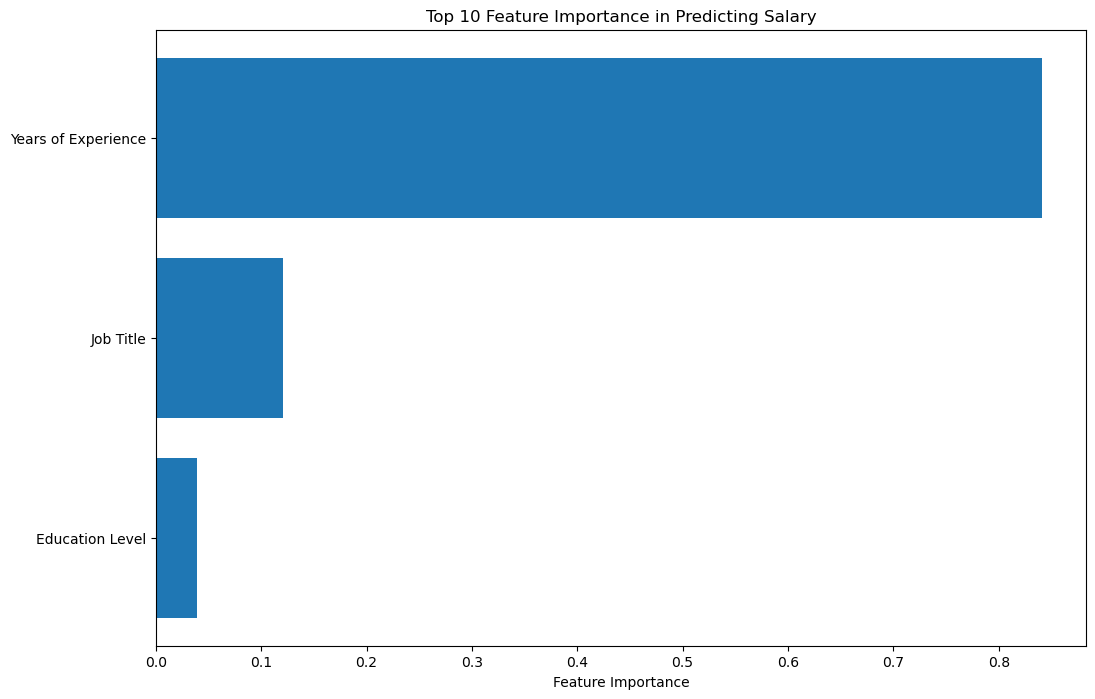

In [99]:
# Access the feature importances of Random Forest Regressor
feature_importances = model3.feature_importances_

# Assuming you have a list of feature names that corresponds to the feature importances
feature_names = list(x_train.columns)

# Sort feature importances in descending order
sorted_indices = np.argsort(feature_importances)[::-1]
sorted_feature_importances = [feature_importances[i] for i in sorted_indices]
sorted_feature_names = [feature_names[i] for i in sorted_indices]

# Create a bar chart
plt.figure(figsize=(12, 8))
plt.barh(sorted_feature_names[:10], sorted_feature_importances[:10])
plt.xlabel('Feature Importance')
plt.title('Top 10 Feature Importance in Predicting Salary')
plt.gca().invert_yaxis()  
plt.show()